<a href="https://colab.research.google.com/github/YeluriSahithi06/AIML_Lab/blob/main/AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [19]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # Calculate the linear output (w * x + b)
                prediction = np.dot(X[i], self.w) + self.b

                # If prediction is a mistake (y * prediction <= 0):
                if y[i] * prediction <= 0:
                    # Update weights: w = w + lr * y * x
                    self.w = self.w + self.lr * y[i] * X[i]
                    # Update bias: b = b + lr * y
                    self.b = self.b + self.lr * y[i]
                    # Increment mistake count for this epoch
                    count += 1

            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# model_p = WaterPerceptron()
# model_p.fit(X_train, y_train)

# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [20]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b

            # Compute Mean Squared Error (MSE) cost and record it
            cost = (1 / (2 * n)) * np.sum((z - y) ** 2)
            self.cost_history.append(cost)

            # 2. Calculate gradients:
            dw = (1 / n) * X.T.dot(z - y)
            db = (1 / n) * np.sum(z - y)

            # 3. Update w and b: w = w - lr * dw
            self.w = self.w - self.lr * dw
            self.b = self.b - self.lr * db
            pass

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [21]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                if y[i] * (np.dot(self.w, x_i) + self.b) >= 1:
                    # Only Regularization update
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

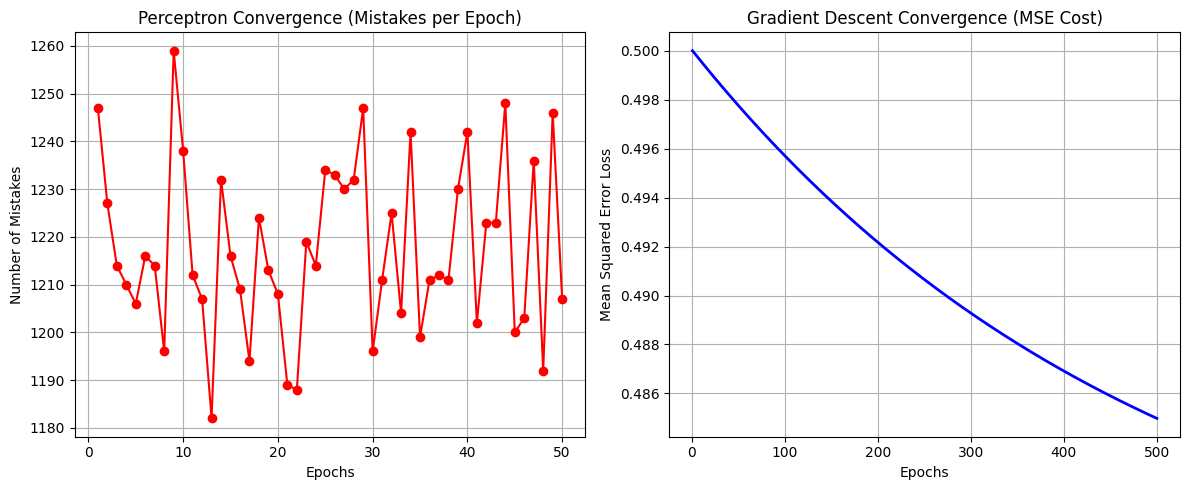

In [22]:
import matplotlib.pyplot as plt

# --- Model Declarations and Training ---
model_p = WaterPerceptron(lr=0.01, epochs=50)
model_gd = GDWaterClassifier(lr=0.001, epochs=500)
model_m = MarginWaterClassifier(lr=0.001, lambda_param=0.01, epochs=500)

model_p.fit(X_train, y_train)
model_gd.fit(X_train, y_train)
model_m.fit(X_train, y_train)
# ----------------------------------------

plt.figure(figsize=(12, 5))

# Plot Perceptron Mistake History
plt.subplot(1, 2, 1)
plt.plot(range(1, len(model_p.mistakes) + 1), model_p.mistakes, color='red', marker='o')
plt.title('Perceptron Convergence (Mistakes per Epoch)')
plt.xlabel('Epochs')
plt.ylabel('Number of Mistakes')
plt.grid(True)

# Plot Gradient Descent Cost History
plt.subplot(1, 2, 2)
plt.plot(range(1, len(model_gd.cost_history) + 1), model_gd.cost_history, color='blue', linewidth=2)
plt.title('Gradient Descent Convergence (MSE Cost)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

In [23]:
# Generate predictions on the test set for all three models
y_pred_perceptron = model_p.predict(X_test)
y_pred_gd = model_gd.predict(X_test)
y_pred_margin = model_m.predict(X_test)

# Calculate accuracy scores
acc_perceptron = np.mean(y_pred_perceptron == y_test)
acc_gd = np.mean(y_pred_gd == y_test)
acc_margin = np.mean(y_pred_margin == y_test)

# Print the final report
print("--- Test Accuracy Report ---")
print(f"1. Perceptron Classifier Accuracy : {acc_perceptron * 100:.2f}%")
print(f"2. GD (MSE) Classifier Accuracy   : {acc_gd * 100:.2f}%")
print(f"3. Margin Classifier Accuracy      : {acc_margin * 100:.2f}%")

--- Test Accuracy Report ---
1. Perceptron Classifier Accuracy : 50.15%
2. GD (MSE) Classifier Accuracy   : 62.80%
3. Margin Classifier Accuracy      : 62.80%


answer to 3:I would trust the Margin Classifier more as the basic Perceptron stops updating the moment it finds any random line that separates the training points, which often means the decision boundary sits dangerously close to one of the data clusters. If a new water sample has a tiny bit of sensor noise, it could easily get flipped to the wrong side. The Margin Classifier explicitly forces a wide, mathematically centered safety buffer between the classes, making it way more robust against borderline variations.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

If I set the learning rate too high, the model takes steps that are way too big and ends up overshooting the optimal minimum point. Instead of settling down and converging, the loss starts to explode and bounce around wildly, causing the whole algorithm to diverge. Basically, the weights change too drastically each time, so the model never actually stabilizes or learns anything useful.

---


### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

Switching the labels to {-1, 1} makes the math for the loss function a lot cleaner and easier to work with, especially for margin-based models like SVMs. When we use {-1, 1}), we can just multiply the true label by our prediction, and a correct guess will always give us a positive number regardless of the class. This symmetry means we don't have to write out separate conditional formulas for 0 and 1, which simplifies things like computing the Hinge Loss down to a single math expression

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*

For a noisy dataset like Water Potability, a Support Vector Machine with a soft margin is the best choice because it doesn't get easily thrown off by random outliers. Thanks to its slack variables, it can intentionally tolerate a few misclassified points instead of twisting the entire decision boundary to fit every single messy data point. It focuses on maximizing the overall margin and finding the main trend, which keeps the model robust against noise.